Pos shape: (2000, 2)
Neg shape: (2000, 2)


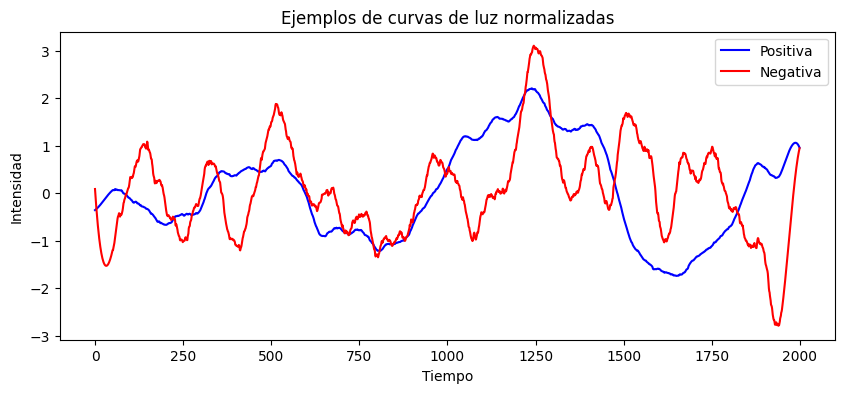

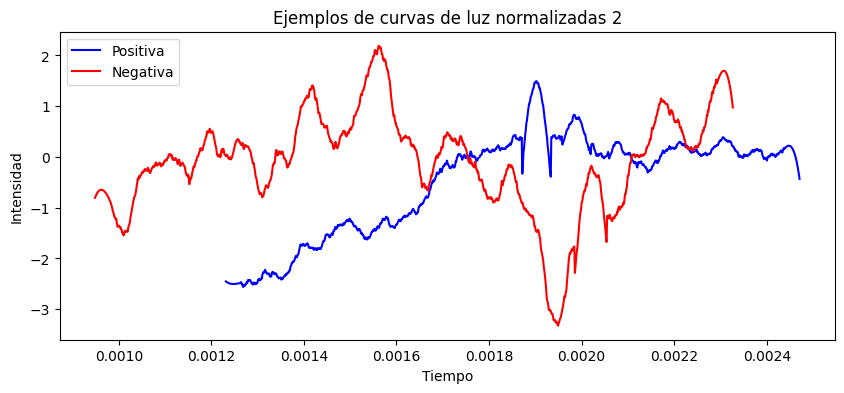

In [6]:
# Visualizar ejemplos
import matplotlib.pyplot as plt
import numpy as np

pos = np.loadtxt("../data/processed/train/positive/positive_0.csv", skiprows=1, delimiter=",")
neg = np.loadtxt("../data/processed/train/negative/negative_0.csv", skiprows=1, delimiter=",")

pos2 = np.loadtxt("../data/processed/train/positive/positive_1.csv", skiprows=1, delimiter=",")
neg2 = np.loadtxt("../data/processed/train/negative/negative_1.csv", skiprows=1, delimiter=",")


print("Pos shape:", pos.shape)
print("Neg shape:", neg.shape)

plt.figure(figsize=(10, 4))
plt.plot(pos[:, 1], label="Positiva", color="blue")
plt.plot(neg[:, 1], label="Negativa", color="red")
plt.legend()
plt.title("Ejemplos de curvas de luz normalizadas")
plt.xlabel("Tiempo")
plt.ylabel("Intensidad")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(pos2[:, 0], pos2[:, 1], label="Positiva", color="blue")
plt.plot(neg2[:, 0], neg2[:, 1], label="Negativa", color="red")
plt.legend()
plt.title("Ejemplos de curvas de luz normalizadas 2")
plt.xlabel("Tiempo")
plt.ylabel("Intensidad")
plt.show()



Época 1/100 - Loss: 0.6952 - Val Loss: 0.6915 - Val Acc: 0.5536
Época 2/100 - Loss: 0.6923 - Val Loss: 0.6889 - Val Acc: 0.5143
Época 3/100 - Loss: 0.6953 - Val Loss: 0.6916 - Val Acc: 0.5250
Época 4/100 - Loss: 0.6916 - Val Loss: 0.6857 - Val Acc: 0.5357
Época 5/100 - Loss: 0.6893 - Val Loss: 0.6899 - Val Acc: 0.5214
Época 6/100 - Loss: 0.6895 - Val Loss: 0.6832 - Val Acc: 0.5607
Época 7/100 - Loss: 0.6884 - Val Loss: 0.6898 - Val Acc: 0.5107
Época 8/100 - Loss: 0.6903 - Val Loss: 0.6791 - Val Acc: 0.5893
Época 9/100 - Loss: 0.6783 - Val Loss: 0.6922 - Val Acc: 0.5500
Época 10/100 - Loss: 0.6853 - Val Loss: 0.6765 - Val Acc: 0.6036
Época 11/100 - Loss: 0.6847 - Val Loss: 0.6907 - Val Acc: 0.5714
Época 12/100 - Loss: 0.6842 - Val Loss: 0.6779 - Val Acc: 0.6000
Época 13/100 - Loss: 0.6832 - Val Loss: 0.6881 - Val Acc: 0.5250
Época 14/100 - Loss: 0.6768 - Val Loss: 0.6729 - Val Acc: 0.6036
Época 15/100 - Loss: 0.6774 - Val Loss: 0.6764 - Val Acc: 0.5857
Época 16/100 - Loss: 0.6828 - Val 

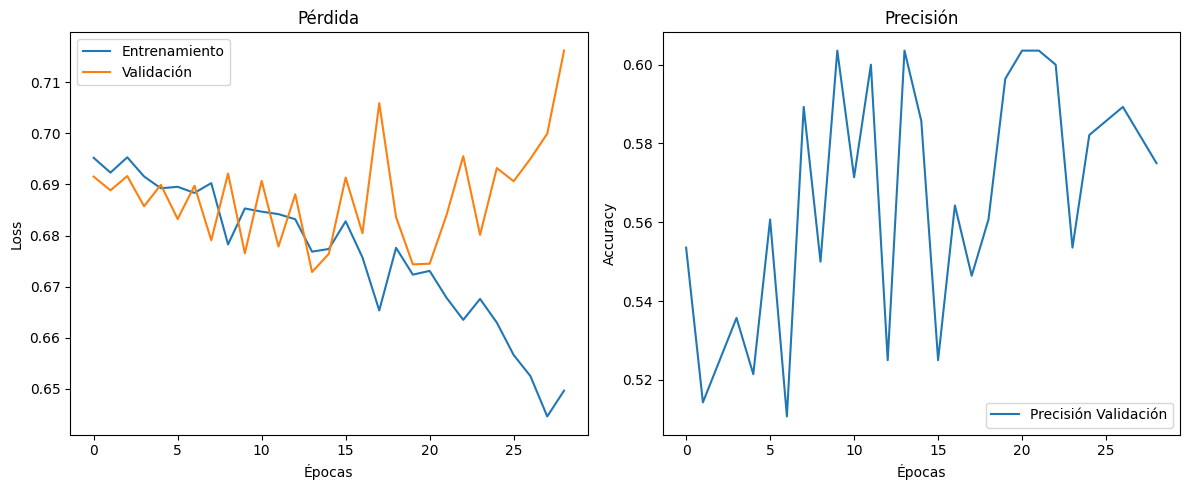

Modelo guardado como final_model.pt


In [1]:
# 1. Importaciones
import numpy as np
import os
import sys
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle


# Asegurar que src está en el path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from src.models.cnn_model import build_model
# 2. Funciones de aumento de datos
def add_noise(signal, noise_level=0.01):
    return signal + noise_level * np.random.randn(*signal.shape)

def time_shift(signal, shift_max=10):
    shift = np.random.randint(-shift_max, shift_max)
    return np.roll(signal, shift)

# 3. Cargar los datos desde carpetas .csv
def load_flux_from_folder(folder_path):
    files = sorted(os.listdir(folder_path))
    data = []
    for file in files:
        if file.endswith('.csv'):
            sample = np.loadtxt(os.path.join(folder_path, file), delimiter=',', skiprows= 1)  # lee CSV
            flux = sample[:, 1]  # columna de brillo
            data.append(flux)
    return np.array(data)

positive = load_flux_from_folder('../data/processed/train/positive')
negative = load_flux_from_folder('../data/processed/train/negative')

# 4. Etiquetado
X = np.concatenate([positive, negative], axis=0)
y = np.concatenate([np.ones(len(positive)), np.zeros(len(negative))], axis=0)

# 5. Mezclar
X, y = shuffle(X, y, random_state=42)

# 6. División train/val
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Convertir a tensores y añadir canal (1, length)
X_train_tensor = torch.tensor(X_train[:, np.newaxis, :], dtype=torch.float32)  # (batch, 1, length)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val[:, np.newaxis, :], dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# 8. Modelo, optimizador y pérdida
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model, optimizer, criterion, scheduler = build_model()
model.to(device)

# 9. Entrenamiento con early stopping
num_epochs = 100
patience = 15
best_val_loss = float('inf')
epochs_without_improvement = 0

train_losses, val_losses, val_accuracies = [], [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Aumento de datos
        np_X = X_batch.squeeze(1).cpu().numpy()
        for i in range(len(np_X)):
            np_X[i] = add_noise(np_X[i], noise_level=0.01)
            np_X[i] = time_shift(np_X[i], shift_max=10)

        X_batch = torch.tensor(np_X[:, np.newaxis, :], dtype=torch.float32).to(device)
        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch.long())
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validación
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch.long())
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = correct / total
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Época {epoch+1}/{num_epochs} - Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f} - Val Acc: {val_accuracy:.4f}")

    scheduler.step(avg_val_loss)

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print("Early stopping activado.")
            break

# 10. Gráficas
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Entrenamiento')
plt.plot(val_losses, label='Validación')
plt.title('Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Precisión Validación')
plt.title('Precisión')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# 11. Guardar modelo final
torch.save(model.state_dict(), '../models/final_model.pt')
print("Modelo guardado como final_model.pt")
